# Симулятор газового куста

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math 
from scipy.optimize import fsolve

from src.fluid      import Fluid
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS
from src.simulator  import FieldSimulator

## Исходные данные

In [ ]:
M     = 0.01604
rho_c = 0.6799
xa    = 0.4561
xy    = 0.7852
T_res = 310.0
P_res    = 100.0

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

V_res     = 3.14 * 500**2 * 25
resprops  = ResProps(P=P_res, V=V_res, T=T_res)
reservoir = Reservoir(resprops=resprops, fluid=fluid)

well_params = [
    dict(k=50, h=25, re=500, rw=0.1, L=2000, H=1800, D=0.062, roughness=4.6e-5, name='Скв-1'),
    dict(k=50, h=25, re=500, rw=0.1, L=2500, H=1900, D=0.062, roughness=4.6e-5, name='Скв-2'),
    dict(k=50, h=25, re=500, rw=0.1, L=1800, H=1600, D=0.073, roughness=4.6e-5, name='Скв-3'),
]

wells = []
for wp in well_params:
    pipe = Pipe(L=wp['L'], D=wp['D'], roughness=wp['roughness'],
                fluid=fluid, vertical_depth=wp['H'], name=wp['name'])
    wells.append(Well(fluid=fluid, k=wp['k'], h=wp['h'],
                      re=wp['re'], rw=wp['rw'], pipe=pipe, name=wp['name']))

shlyf = Pipe(L=5000, D=0.200, roughness=4.6e-5, fluid=fluid,
             vertical_depth=0.0, name='Шлейф')
dcs   = DCS(CR=1.5, P_line=5.0, q_ext=500.0)
sim   = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

print(f'V_res = {V_res/1e6:.3f} млн м³  |  P_in ДКС = {dcs.P_in():.2f} атм')

V_res = 19.625 млн м³  |  P_in ДКС = 3.33 атм


## 1. PVT-модель

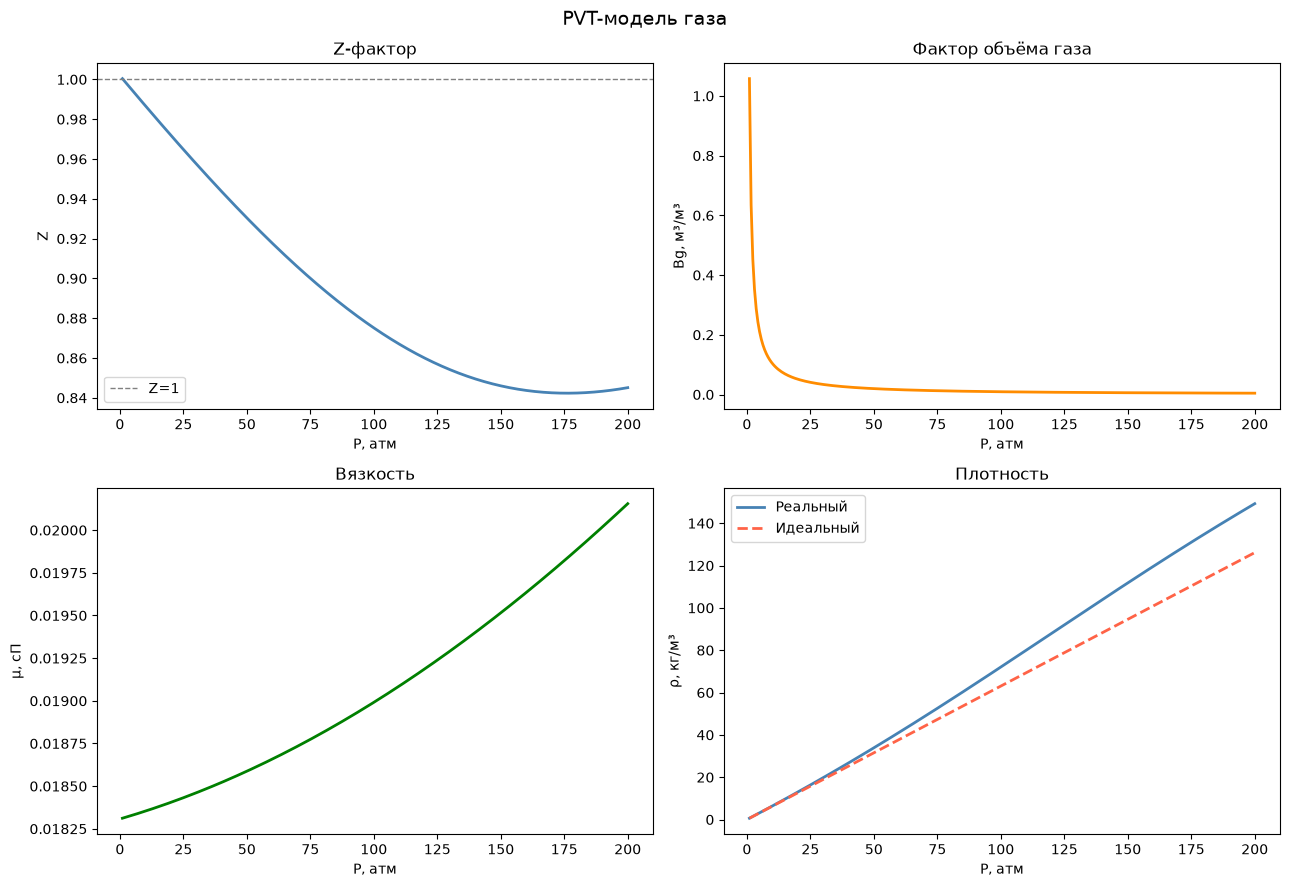

Z(100)  = 0.8752
ρ(100)  = 72.05 кг/м³
Bg(100) = 0.00925 м³/м³
ρ_std   = 0.6668 кг/м³


In [ ]:
P_range  = np.linspace(1, 200, 300)
Z_vals   = [fluid.z(p)  for p in P_range]
Bg_vals  = [fluid.bg(p) for p in P_range]
mu_vals  = [fluid.mu(p) for p in P_range]
ro_real  = [fluid.ro(p) for p in P_range]
ro_ideal = [p * 101325 * M / (8.314 * T_res) for p in P_range]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('PVT-модель газа', fontsize=14)

axes[0,0].plot(P_range, Z_vals, 'steelblue', lw=2)
axes[0,0].axhline(1.0, color='gray', ls='--', lw=1, label='Z=1')
axes[0,0].set(xlabel='P, атм', ylabel='Z', title='Z-фактор')
axes[0,0].legend()

axes[0,1].plot(P_range, Bg_vals, 'darkorange', lw=2)
axes[0,1].set(xlabel='P, атм', ylabel='Bg, м³/м³', title='Фактор объёма газа')

axes[1,0].plot(P_range, mu_vals, 'green', lw=2)
axes[1,0].set(xlabel='P, атм', ylabel='μ, сП', title='Вязкость')

axes[1,1].plot(P_range, ro_real,  'steelblue', lw=2, label='Реальный')
axes[1,1].plot(P_range, ro_ideal, 'tomato', lw=2, ls='--', label='Идеальный')
axes[1,1].set(xlabel='P, атм', ylabel='ρ, кг/м³', title='Плотность')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Z(100)  = {fluid.z(100):.4f}')
print(f'ρ(100)  = {fluid.ro(100):.2f} кг/м³')
print(f'Bg(100) = {fluid.bg(100):.5f} м³/м³')
print(f'ρ_std   = {fluid.ro_std():.4f} кг/м³')

## 2. Кривые IPR

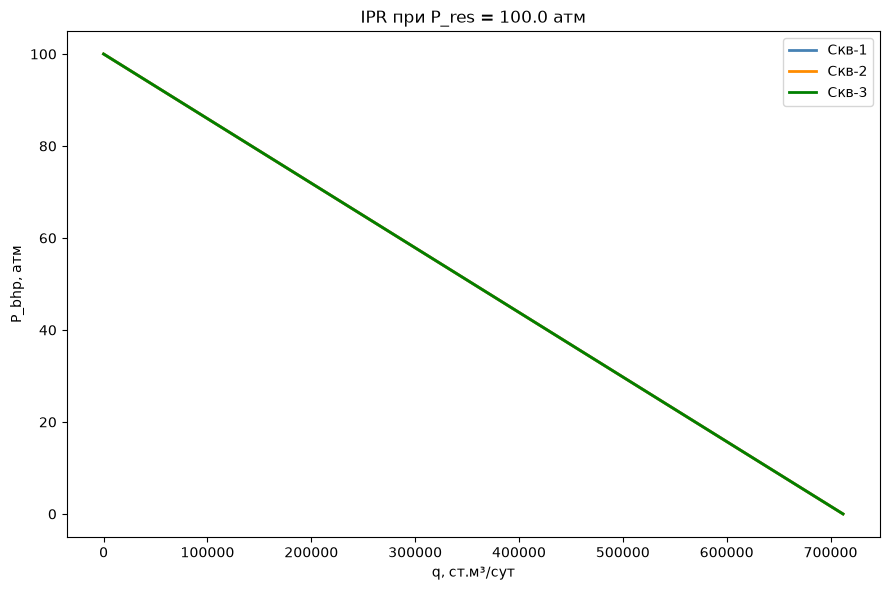

In [ ]:
P_res_test = 100.0
colors     = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(9, 6))
for well, color in zip(wells, colors):
    pts = well.ipr(P_res_test, n_points=100)
    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=color, lw=2, label=well.name)
ax.set(xlabel='q, ст.м³/сут', ylabel='P_bhp, атм',
       title=f'IPR при P_res = {P_res_test} атм')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Гидравлика — VLP и λ(Re)

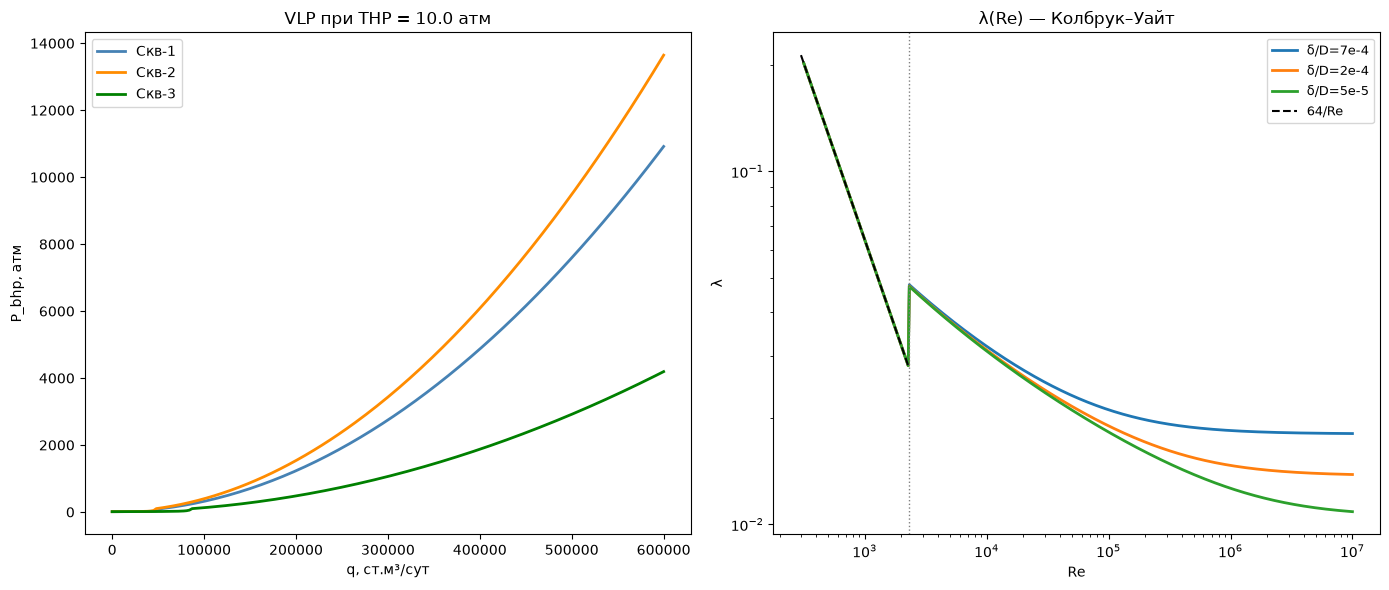

In [ ]:
THP = 10.0  # давление на устье, атм

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for well, color in zip(wells, colors):
    pts = well.vlp(THP, q_max=600000, n_points=200)
    axes[0].plot([p[0] for p in pts], [p[1] for p in pts],
                 color=color, lw=2, label=well.name)
axes[0].set(xlabel='q, ст.м³/сут', ylabel='P_bhp, атм',
            title=f'VLP при THP = {THP} атм')
axes[0].legend()

Re_range   = np.logspace(2.5, 7, 500)
eps_vals   = [7e-4, 2e-4, 5e-5]
eps_labels = ['δ/D=7e-4', 'δ/D=2e-4', 'δ/D=5e-5']
for eps, lbl, color in zip(eps_vals, eps_labels, colors):
    lam_vals = [wells[0].pipe._friction_factor(Re, eps) for Re in Re_range]
    axes[1].loglog(Re_range, lam_vals, lw=2, label=lbl)
axes[1].loglog(np.linspace(300, 2300, 50), 64/np.linspace(300,2300,50),
               'k--', lw=1.5, label='64/Re')
axes[1].axvline(2300, color='gray', ls=':', lw=1)
axes[1].set(xlabel='Re', ylabel='λ', title='λ(Re) — Колбрук–Уайт')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Рабочая точка — IPR ∩ VLP

P_man (реальное) = 53.19 атм | P_in ДКС = 3.33 атм



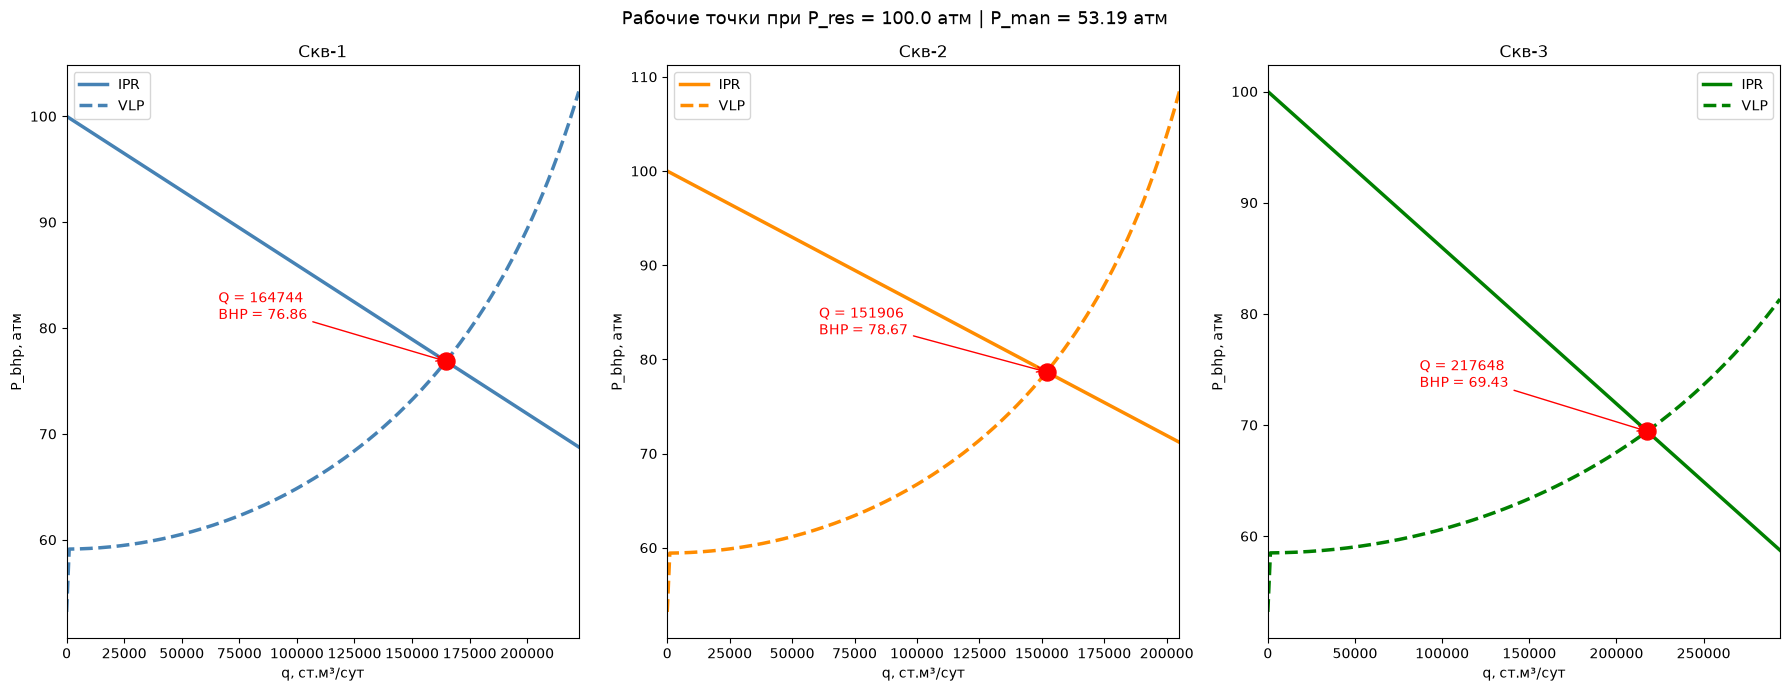

In [ ]:
reservoir.resprops.P = P_res
P_res_test = 100.0
colors = ['steelblue', 'darkorange', 'green']

states_wp = sim.solve(P_res_test)
P_man_real = states_wp['well_1'].P_out

print(f'P_man (реальное) = {P_man_real:.2f} атм | P_in ДКС = {dcs.P_in():.2f} атм\n')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for idx, (well, color) in enumerate(zip(wells, colors)):
    ax = axes[idx]
    key = f'well_{idx+1}'
    
    q_op   = states_wp[key].q_std
    bhp_op = states_wp[key].P_in
    
    q_max = q_op * 1.35
    q_range = np.linspace(0, q_max, 200)
    
    # === IPR: точный расчёт через fsolve ===
    bhp_ipr = []
    for q in q_range:
        def func(p):
            if p <= 0: return 1e8
            return well.q(P_res_test, p) - q
        
        guess = max(bhp_op - 5, P_res_test * 0.6)
        sol = fsolve(func, guess, xtol=1e-10, maxfev=3000)
        bhp_ipr.append(max(sol[0], 0.0))
    
    # === VLP ===
    bhp_vlp = [P_man_real + well.pipe.dp(P_man_real, q).dP for q in q_range]
    
    ax.plot(q_range, bhp_ipr, color=color, lw=2.5, label='IPR')
    ax.plot(q_range, bhp_vlp, color=color, lw=2.5, ls='--', label='VLP')
    
    ax.scatter([q_op], [bhp_op], color='red', s=150, zorder=5)
    ax.annotate(f'Q = {q_op:.0f}\nBHP = {bhp_op:.2f}',
                xy=(q_op, bhp_op),
                xytext=(q_op*0.4, bhp_op + 4),
                color='red', fontsize=10,
                arrowprops=dict(arrowstyle='->', color='red'))
    
    ax.set_xlabel('q, ст.м³/сут')
    ax.set_ylabel('P_bhp, атм')
    ax.set_title(well.name)
    ax.set_xlim(0, q_max)
    ax.legend()

plt.suptitle(f'Рабочие точки при P_res = {P_res_test} атм | P_man = {P_man_real:.2f} атм', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Динамика

In [ ]:
reservoir.resprops.P = P_res
df = sim.run(N_days=1000, dt=1.0)

Запуск симуляции на 1000 суток...
День    0 | P_res = 100.00 атм


c:\Users\Devras\Downloads\gas_field_simulator\src\simulator.py:44: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equations, x0, xtol=1e-8, maxfev=2000)


День   30 | P_res = 99.25 атм
День   60 | P_res = 98.50 атм
День   90 | P_res = 97.75 атм
День  120 | P_res = 97.01 атм


c:\Users\Devras\Downloads\gas_field_simulator\src\simulator.py:44: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(equations, x0, xtol=1e-8, maxfev=2000)


День  150 | P_res = 96.28 атм
День  180 | P_res = 95.55 атм
День  210 | P_res = 94.83 атм
День  240 | P_res = 94.11 атм
День  270 | P_res = 93.40 атм
День  300 | P_res = 92.69 атм
День  330 | P_res = 91.99 атм
День  360 | P_res = 91.29 атм
День  390 | P_res = 90.60 атм
День  420 | P_res = 89.91 атм
День  450 | P_res = 89.23 атм
День  480 | P_res = 88.56 атм
День  510 | P_res = 87.89 атм
День  540 | P_res = 87.22 атм
День  570 | P_res = 86.56 атм
День  600 | P_res = 85.91 атм
День  630 | P_res = 85.26 атм
День  660 | P_res = 84.61 атм
День  690 | P_res = 83.97 атм
День  720 | P_res = 83.34 атм
День  750 | P_res = 82.71 атм
День  780 | P_res = 82.09 атм
День  810 | P_res = 81.47 атм
День  840 | P_res = 80.86 атм
День  870 | P_res = 80.25 атм
День  900 | P_res = 79.65 атм
День  930 | P_res = 79.06 атм
День  960 | P_res = 78.47 атм
День  990 | P_res = 77.89 атм
День 1000 | P_res = 77.69 атм
Симуляция завершена.



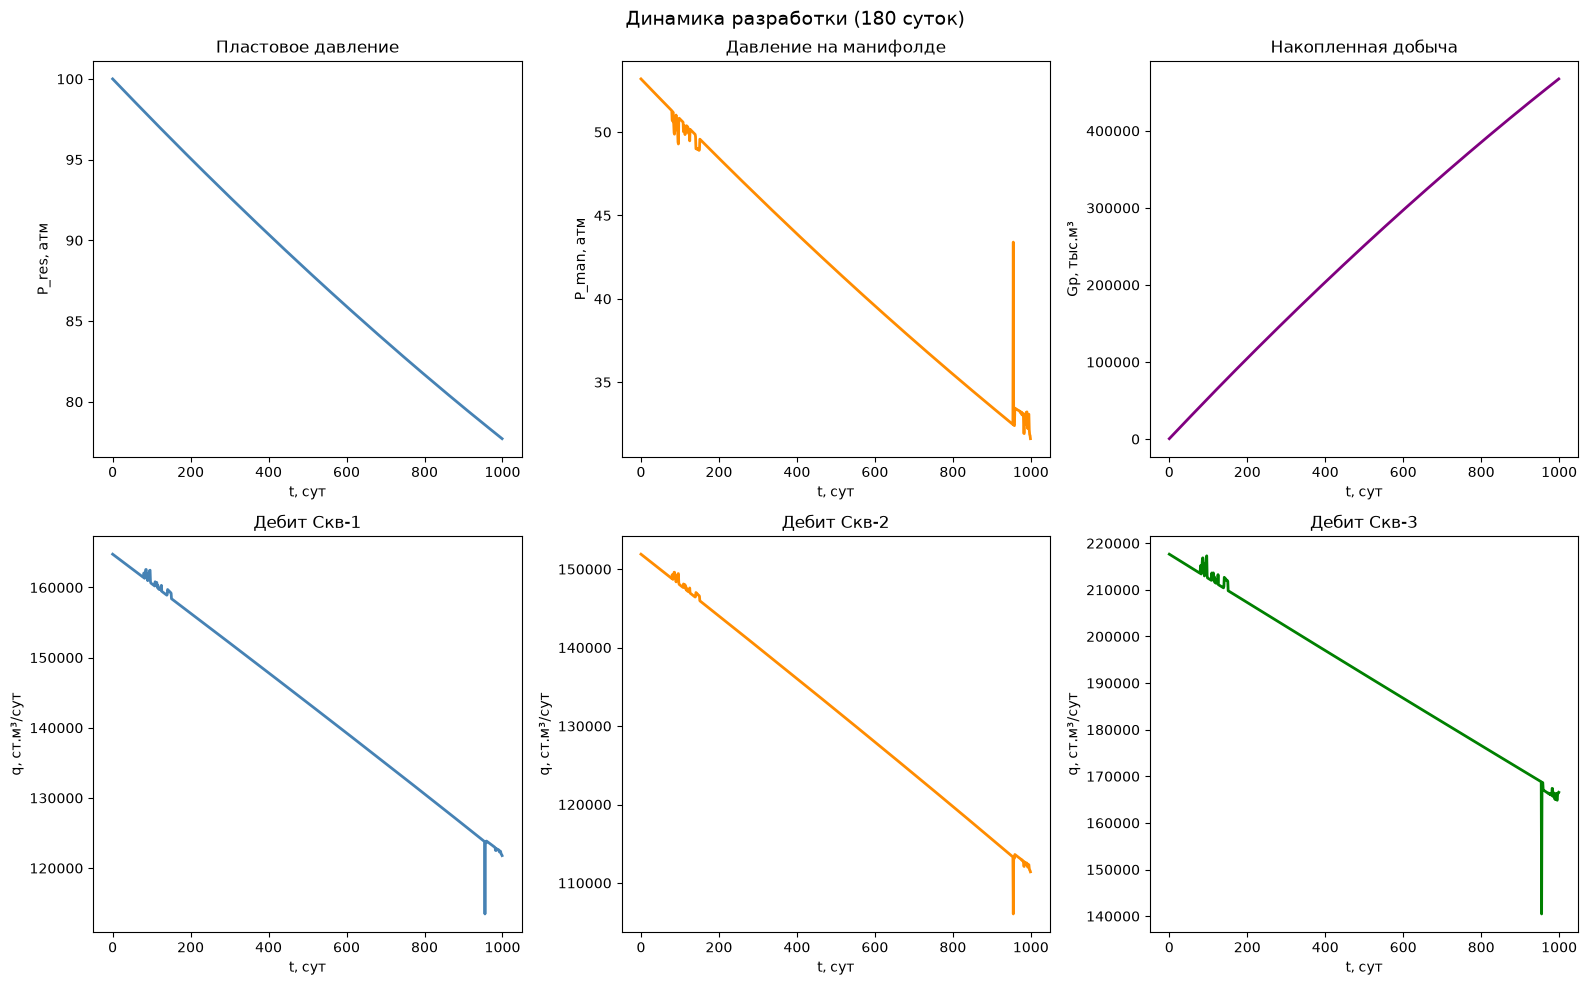

P_res конец: 77.71 атм
Gp итого:    467410.9 тыс.м³


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Динамика разработки (180 суток)', fontsize=14)
t = df['t']

axes[0,0].plot(t, df['P_res'], 'steelblue', lw=2)
axes[0,0].set(xlabel='t, сут', ylabel='P_res, атм', title='Пластовое давление')

axes[0,1].plot(t, df['P_man'], 'darkorange', lw=2)
axes[0,1].set(xlabel='t, сут', ylabel='P_man, атм', title='Давление на манифолде')

axes[0,2].plot(t, df['Gp'], 'purple', lw=2)
axes[0,2].set(xlabel='t, сут', ylabel='Gp, тыс.м³', title='Накопленная добыча')

for i, (col, color) in enumerate(zip(['q1','q2','q3'], colors)):
    axes[1,i].plot(t, df[col], color=color, lw=2)
    axes[1,i].set(xlabel='t, сут', ylabel='q, ст.м³/сут',
                  title=f'Дебит {wells[i].name}')

plt.tight_layout()
plt.show()
print(f'P_res конец: {df["P_res"].iloc[-1]:.2f} атм')
print(f'Gp итого:    {df["Gp"].iloc[-1]:.1f} тыс.м³')

## 6. Анализ влияния CR

In [ ]:
P_res = 100
CR_values  = [1.0, 1.5, 2.0, 3.0]
cr_colors  = ['gray', 'steelblue', 'darkorange', 'red']
results_cr = {}

for CR in CR_values:
    reservoir.resprops.P = P_res
    dcs.set_compression_ratio(CR)
    sim_cr        = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)
    df_cr         = sim_cr.run(N_days=1000, dt=1.0)
    results_cr[CR] = df_cr
    print(f'CR={CR}: Gp={df_cr["Gp"].iloc[-1]:.1f} тыс.м³, '
          f'P_res={df_cr["P_res"].iloc[-1]:.2f} атм')

dcs.set_compression_ratio(1.5)

Запуск симуляции на 1000 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.25 атм
День   60 | P_res = 98.51 атм
День   90 | P_res = 97.77 атм
День  120 | P_res = 97.04 атм
День  150 | P_res = 96.31 атм
День  180 | P_res = 95.59 атм
День  210 | P_res = 94.87 атм
День  240 | P_res = 94.16 атм
День  270 | P_res = 93.45 атм
День  300 | P_res = 92.75 атм
День  330 | P_res = 92.05 атм
День  360 | P_res = 91.36 атм
День  390 | P_res = 90.68 атм
День  420 | P_res = 90.00 атм
День  450 | P_res = 89.32 атм
День  480 | P_res = 88.65 атм
День  510 | P_res = 87.98 атм
День  540 | P_res = 87.32 атм
День  570 | P_res = 86.67 атм
День  600 | P_res = 86.01 атм
День  630 | P_res = 85.37 атм
День  660 | P_res = 84.73 атм
День  690 | P_res = 84.09 атм
День  720 | P_res = 83.46 атм
День  750 | P_res = 82.84 атм
День  780 | P_res = 82.22 атм
День  810 | P_res = 81.60 атм
День  840 | P_res = 80.99 атм
День  870 | P_res = 80.39 атм
День  900 | P_res = 79.79 атм
День  930 | P_res = 79.20 атм
День 

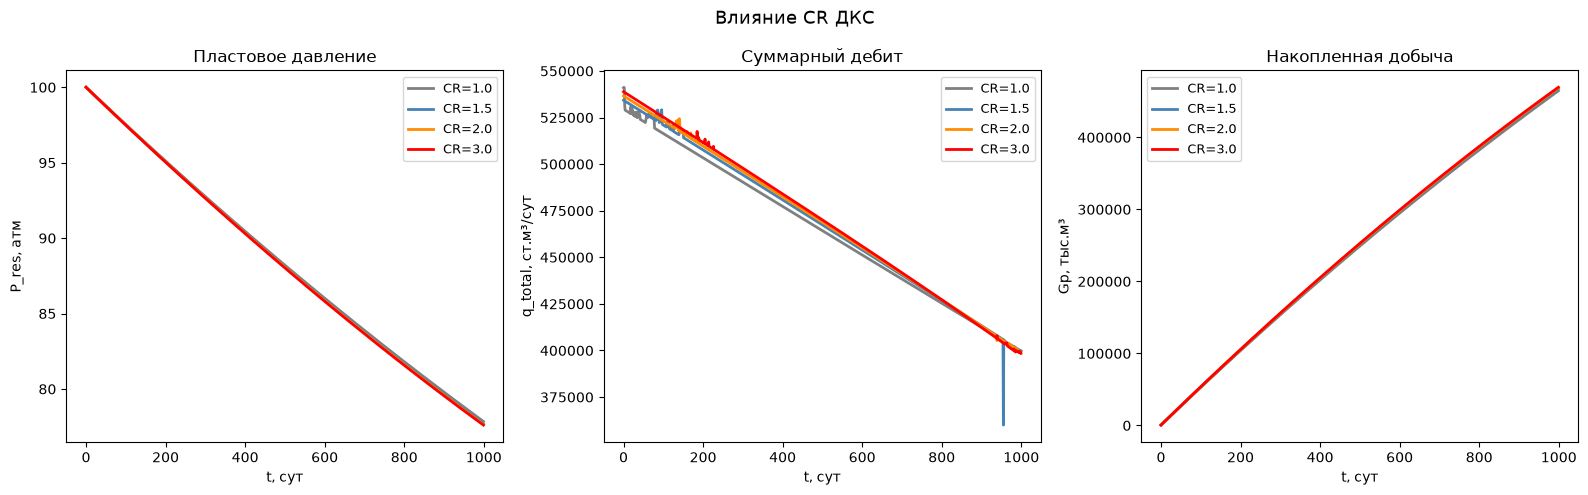

   CR     P_res конец    Gp, тыс.м³
  1.0           77.85      464602.4
  1.5           77.71      467410.9
  2.0           77.65      468621.1
  3.0           77.61      469542.9


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Влияние CR ДКС', fontsize=13)

for CR, color in zip(CR_values, cr_colors):
    d   = results_cr[CR]
    lbl = f'CR={CR}'
    axes[0].plot(d['t'], d['P_res'],   color=color, lw=2, label=lbl)
    axes[1].plot(d['t'], d['q_total'], color=color, lw=2, label=lbl)
    axes[2].plot(d['t'], d['Gp'],      color=color, lw=2, label=lbl)

axes[0].set(xlabel='t, сут', ylabel='P_res, атм',       title='Пластовое давление')
axes[1].set(xlabel='t, сут', ylabel='q_total, ст.м³/сут', title='Суммарный дебит')
axes[2].set(xlabel='t, сут', ylabel='Gp, тыс.м³',       title='Накопленная добыча')
for ax in axes: ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'{"CR":>5}  {"P_res конец":>14}  {"Gp, тыс.м³":>12}')
for CR in CR_values:
    d = results_cr[CR]
    print(f'{CR:>5}  {d["P_res"].iloc[-1]:>14.2f}  {d["Gp"].iloc[-1]:>12.1f}')

## 7. Калибровка


In [ ]:

import os
from scipy.optimize import minimize

calib_path = 'adapt_gdi_11-2025.csv'
df_fact = pd.read_csv(calib_path, sep=',')
if df_fact.columns[0] == 'Unnamed: 0':                    
    df_fact = df_fact.iloc[:, 1:]                         
df_fact = df_fact.dropna()                                
q_col = 'q_std' if 'q_std' in df_fact.columns else 'q'    

print(f'Загружено {len(df_fact)} замеров. По скважинам:',
      df_fact['well_name'].value_counts().to_dict())


well_to_idx = {'well_1': 0, 'well_2': 1, 'well_3': 2}


def fit_kh_for_well(well, df_well):
    
    k_orig  = well.k                                      
    h_const = well.h                                     

    try:
        def rmse(kh_arr):                                
            kh = float(kh_arr[0])                        
            if kh <= 0: return 1e10                     
            well.k = kh / h_const                        
            q_pred = np.array([well.q(r['P_res'], r['P_bhp'])
                               for _, r in df_well.iterrows()])    
            return np.sqrt(np.mean((q_pred - df_well[q_col].values)**2))

        opt    = minimize(rmse, x0=[1250.0], method='Nelder-Mead',
                          options={'xatol': 1e-4})       
        kh_opt = float(opt.x[0])

        well.k = kh_opt / h_const
        q_pred = np.array([well.q(r['P_res'], r['P_bhp'])
                           for _, r in df_well.iterrows()])
        q_f    = df_well[q_col].values
        rmse_v = float(np.sqrt(np.mean((q_pred - q_f)**2)))
        r2     = float(1 - np.sum((q_f - q_pred)**2) / np.sum((q_f - q_f.mean())**2))
        return kh_opt, rmse_v, r2, q_pred
    finally:
        well.k = k_orig                                  


results = {}                                              
for wn, idx in well_to_idx.items():
    if wn not in df_fact['well_name'].values:             
        continue
    d_w = df_fact[df_fact['well_name'] == wn].copy()      
    kh_opt, rmse_v, r2, q_pred = fit_kh_for_well(wells[idx], d_w)
    results[wn] = dict(kh_opt=kh_opt, rmse=rmse_v, r2=r2,
                       q_pred=q_pred, df=d_w)
    print(f'  {wn}: kh_opt = {kh_opt:>7.0f} мД·м  '
          f'(k = {kh_opt/wells[idx].h:5.1f} мД при h={wells[idx].h})  '
          f'RMSE = {rmse_v:>7.1f}   R² = {r2:.4f}')


Загружено 50 замеров. По скважинам: {'well_2': 18, 'well_1': 18, 'well_3': 14}
  well_1: kh_opt =    2299 мД·м  (k =  92.0 мД при h=25)  RMSE =    48.1   R² = 0.9996
  well_2: kh_opt =    4364 мД·м  (k = 174.6 мД при h=25)  RMSE =   101.1   R² = 0.9997
  well_3: kh_opt =    3108 мД·м  (k = 124.3 мД при h=25)  RMSE =   169.9   R² = 0.9997


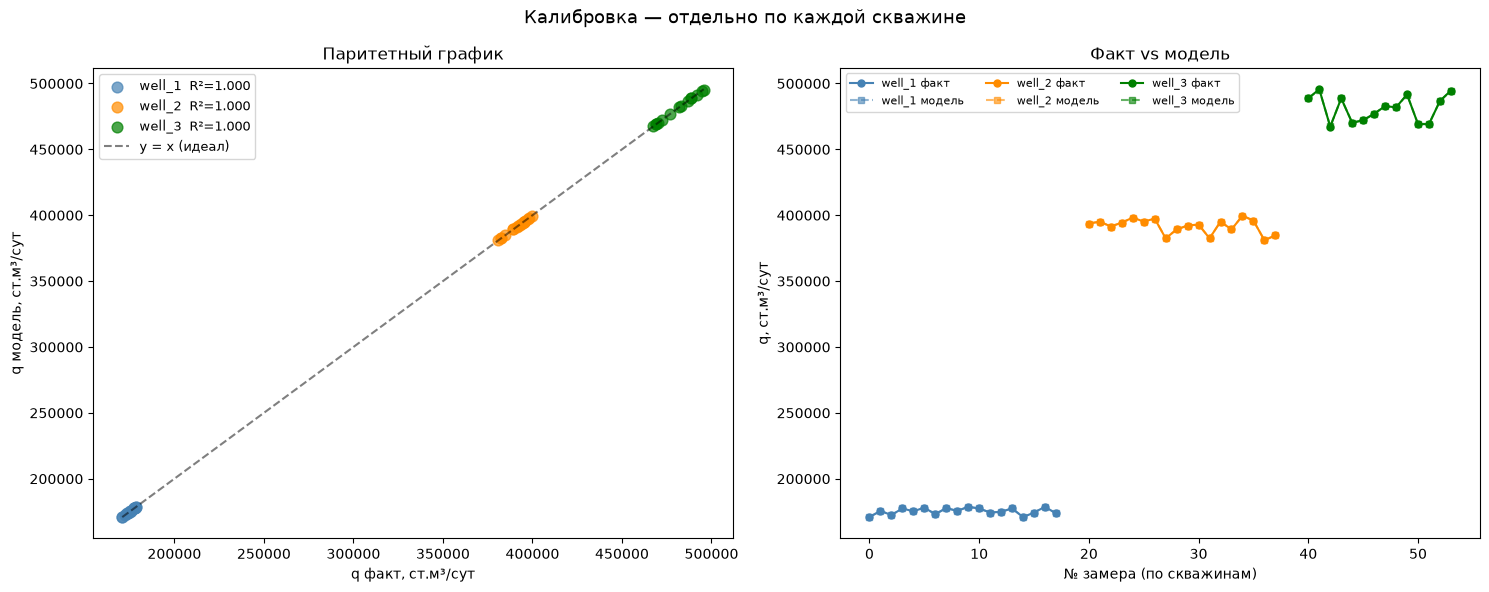


    Скв      kh_opt   k_opt, мД        RMSE        R²
 well_1        2299        92.0        48.1    0.9996
 well_2        4364       174.6       101.1    0.9997
 well_3        3108       124.3       169.9    0.9997


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Калибровка — отдельно по каждой скважине', fontsize=13)

well_colors = {'well_1':'steelblue', 'well_2':'darkorange', 'well_3':'green'}

all_qf, all_qp = [], []
for wn, r in results.items():
    qf, qp = r['df'][q_col].values, r['q_pred']
    axes[0].scatter(qf, qp, color=well_colors[wn], s=60, alpha=0.7,
                    label=f'{wn}  R²={r["r2"]:.3f}')
    all_qf.extend(qf); all_qp.extend(qp)

lim = [min(min(all_qf), min(all_qp)), max(max(all_qf), max(all_qp))]
axes[0].plot(lim, lim, 'k--', lw=1.5, alpha=0.5, label='y = x (идеал)')
axes[0].set(xlabel='q факт, ст.м³/сут', ylabel='q модель, ст.м³/сут',
            title='Паритетный график')
axes[0].legend(fontsize=9)

offset = 0                                               
for wn, r in results.items():
    n  = len(r['df'])
    xs = np.arange(offset, offset+n)
    axes[1].plot(xs, r['df'][q_col].values, 'o-',
                 color=well_colors[wn], ms=5, label=f'{wn} факт')
    axes[1].plot(xs, r['q_pred'],          's--',
                 color=well_colors[wn], ms=5, alpha=0.6, label=f'{wn} модель')
    offset += n + 2                                       
axes[1].set(xlabel='№ замера (по скважинам)', ylabel='q, ст.м³/сут',
            title='Факт vs модель')
axes[1].legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

print(f'\n{"Скв":>7}  {"kh_opt":>10}  {"k_opt, мД":>10}  {"RMSE":>10}  {"R²":>8}')
for wn, r in results.items():
    print(f'{wn:>7}  {r["kh_opt"]:>10.0f}  {r["kh_opt"]/wells[well_to_idx[wn]].h:>10.1f}  '
          f'{r["rmse"]:>10.1f}  {r["r2"]:>8.4f}')


## 8. Динамика «до и после» калибровки


Запуск симуляции на 300 суток...
День    0 | P_res = 100.00 атм


c:\Users\Devras\Downloads\gas_field_simulator\src\simulator.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equations, x0, xtol=1e-10, maxfev=5000)
c:\Users\Devras\Downloads\gas_field_simulator\src\simulator.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(equations, x0, xtol=1e-10, maxfev=5000)


День   30 | P_res = 99.25 атм
День   60 | P_res = 98.50 атм
День   90 | P_res = 97.75 атм
День  120 | P_res = 97.02 атм
День  150 | P_res = 96.28 атм
День  180 | P_res = 95.56 атм
День  210 | P_res = 94.83 атм
День  240 | P_res = 94.12 атм
День  270 | P_res = 93.40 атм
День  300 | P_res = 92.70 атм
Симуляция завершена.

Запуск симуляции на 300 суток...
День    0 | P_res = 100.00 атм
День   30 | P_res = 99.12 атм
День   60 | P_res = 98.28 атм
День   90 | P_res = 97.44 атм
День  120 | P_res = 96.61 атм
День  150 | P_res = 95.78 атм
День  180 | P_res = 94.95 атм
День  210 | P_res = 94.13 атм
День  240 | P_res = 93.32 атм
День  270 | P_res = 92.51 атм
День  300 | P_res = 91.70 атм
Симуляция завершена.



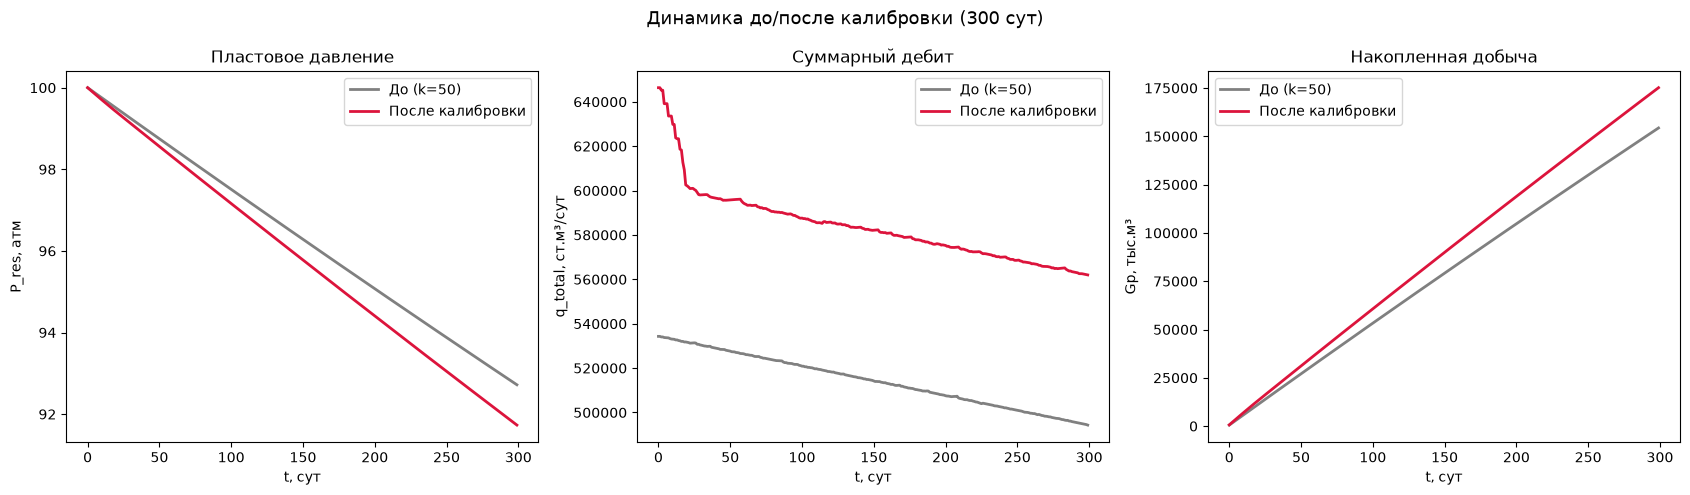


             P_res конец    Gp, тыс.м³    q_total средн.
        ДО         92.72      154320.6            514402
     ПОСЛЕ         91.73       175162.2            583874

Откалиброванные проницаемости:
  Скв-1: k = 92.0 мД (было 50)
  Скв-2: k = 174.6 мД (было 50)
  Скв-3: k = 124.3 мД (было 50)


In [ ]:

Days = 300                                       

k_original = [50.0, 50.0, 50.0]                          
for w, k in zip(wells, k_original):
    w.k = k
reservoir.resprops.P = P_res                            
dcs.set_compression_ratio(1.5)                            
df_before = sim.run(N_days=Days, dt=1.0)

for wn, idx in well_to_idx.items():
    if wn in results:
        wells[idx].k = results[wn]['kh_opt'] / wells[idx].h     
reservoir.resprops.P = P_res                            
df_after = sim.run(N_days=Days, dt=1.0)


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Динамика до/после калибровки ({Days} сут)', fontsize=13)

axes[0].plot(df_before['t'], df_before['P_res'], 'gray',      lw=2, label='До (k=50)')
axes[0].plot(df_after['t'],  df_after['P_res'],  'crimson',   lw=2, label='После калибровки')
axes[0].set(xlabel='t, сут', ylabel='P_res, атм', title='Пластовое давление')
axes[0].legend()

axes[1].plot(df_before['t'], df_before['q_total'], 'gray',    lw=2, label='До (k=50)')
axes[1].plot(df_after['t'],  df_after['q_total'],  'crimson', lw=2, label='После калибровки')
axes[1].set(xlabel='t, сут', ylabel='q_total, ст.м³/сут', title='Суммарный дебит')
axes[1].legend()

axes[2].plot(df_before['t'], df_before['Gp'], 'gray',    lw=2, label='До (k=50)')
axes[2].plot(df_after['t'],  df_after['Gp'],  'crimson', lw=2, label='После калибровки')
axes[2].set(xlabel='t, сут', ylabel='Gp, тыс.м³', title='Накопленная добыча')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\n{"":>10} {"P_res конец":>13} {"Gp, тыс.м³":>13} {"q_total средн.":>17}')
print(f'{"ДО":>10} {df_before["P_res"].iloc[-1]:>13.2f} {df_before["Gp"].iloc[-1]:>13.1f} {df_before["q_total"].mean():>17.0f}')
print(f'{"ПОСЛЕ":>10} {df_after["P_res"].iloc[-1]:>13.2f}  {df_after["Gp"].iloc[-1]:>13.1f} {df_after["q_total"].mean():>17.0f}')
print(f'\nОткалиброванные проницаемости:')
for w in wells:
    print(f'  {w.name}: k = {w.k:.1f} мД (было 50)')
